# Project Innowise



In [1]:
%pip install numpy pandas matplotlib seaborn plotly nbformat

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 2.7 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.7 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.7 MB 1.9 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.7 MB 1.9 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.7 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.7 MB 1.8 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.7 MB 1.7 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/9.7 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 3.1/9.7 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.7 MB 1.6 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.7 MB 1.6 MB/s eta 0:00:04
   ----------------- -----


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from jedi.inference import lazy_value
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Merge data


In [3]:
items = pd.read_csv('olist_order_items_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')
df = (items.merge(orders, on='order_id', how='left')
           .merge(customers, on='customer_id', how='left')
           .merge(products, on='product_id', how='left')
           .merge(translations, on='product_category_name', how='left'))

display(df.head(30))

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:34,2017-05-17 03:55:27,2017-05-17 11:05:55,2017-05-22 13:44:35,2017-06-06 00:00:00,85c835d128beae5b4ce8602c491bf385,38017,uberaba,MG,utilidades_domesticas,36.0,558.0,1.0,450.0,24.0,8.0,15.0,housewares
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85,32e2e6ab09e778d99bf2e0ecd4898718,delivered,2017-12-10 11:53:48,2017-12-10 12:10:31,2017-12-12 01:07:48,2017-12-18 22:03:38,2018-01-04 00:00:00,635d9ac1680f03288e72ada3a1035803,16700,guararapes,SP,telefonia,52.0,815.0,1.0,200.0,27.0,5.0,20.0,telephony
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75,9ed5e522dd9dd85b4af4a077526d8117,delivered,2018-07-04 12:08:27,2018-07-05 16:35:48,2018-07-05 12:15:00,2018-07-09 14:04:07,2018-07-25 00:00:00,fda4476abb6307ab3c415b7e6d026526,11702,praia grande,SP,ferramentas_jardim,39.0,1310.0,3.0,13805.0,35.0,75.0,45.0,garden_tools
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,16150771dfd4776261284213b89c304e,delivered,2018-03-19 18:40:33,2018-03-20 18:35:21,2018-03-28 00:37:42,2018-03-29 18:17:31,2018-03-29 00:00:00,639d23421f5517f69d0c3d6e6564cf0e,11075,sant

Adding finantial data

In [4]:
to_delete = ['product_category_name','product_name_lenght','product_description_lenght','product_photos_qty','customer_zip_code_prefix','product_photos_qty','order_approved_at','order_delivered_carrier_date','shipping_limit_date','order_estimated_delivery_date','product_length_cm','product_width_cm','product_height_cm','seller_id','order_item_id']
df = df.drop(columns=to_delete, errors='ignore')
print(df.columns.tolist())

['order_id', 'product_id', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'customer_unique_id', 'customer_city', 'customer_state', 'product_weight_g', 'product_category_name_english']


In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
np.random.seed(24)
df['cost_multiplier'] = np.random.uniform(0.40, 0.70, size=len(df))
df['product_cost'] = round(df['cost_multiplier'] * df['price'],2)
df['profit_margin'] = df['price'] - df['product_cost']
check = df.groupby('product_category_name_english').size().sort_values(ascending=False)
print(len(check))

71


Mapping departments for categories

In [6]:
department_groups = {
    'Home & Living': ['bed_bath_table', 'furniture_decor', 'housewares', 'garden_tools',
                      'home_construction', 'office_furniture', 'home_confort',
                      'furniture_living_room', 'home_appliances', 'home_appliances_2'],

    'Health & Beauty': ['health_beauty', 'perfumery', 'baby', 'diapers_and_hygiene'],

    'Tech & Electronics': ['computers_accessories', 'telephony', 'electronics', 'audio',
                           'computers', 'fixed_telephony', 'tablets_printing_image'],

    'Fashion & Accessories': ['watches_gifts', 'fashion_bags_accessories', 'fashion_shoes',
                              'fashion_male_clothing', 'fashion_female_clothing',
                              'fashion_underwear_beach', 'luggage_accessories'],

    'Sports & Leisure': ['sports_leisure', 'toys', 'consoles_games', 'musical_instruments'],

    'Auto & Tools': ['auto', 'construction_tools_construction', 'costruction_tools_tools',
                     'industry_commerce_and_business'],

    'Books & Media': ['stationery', 'books_general_interest', 'books_technical',
                      'books_imported', 'cds_dvds_musicals', 'dvds_blu_ray'],

    'Food & Drinks': ['food', 'drinks', 'food_drink']
}

full_maping = {}
for dept, categories in department_groups.items():
    for category in categories:
        full_maping[category] = dept
df['Department'] = df['product_category_name_english'].map(full_maping).fillna('Other')
display(df.groupby('Department').size().sort_values(ascending=False))

Department
Home & Living            35001
Health & Beauty          16193
Tech & Electronics       16053
Sports & Leisure         14575
Other                    11012
Fashion & Accessories     9639
Auto & Tools              5535
Books & Media             3475
Food & Drinks             1167
dtype: int64

Loyalty program


In [7]:
df['Loyalty_Status'] = 'Standard'
scd_date = pd.to_datetime('2018-01-01')
unique_cust = df['customer_unique_id'].dropna().unique()
prem_cust = np.random.choice(unique_cust, size=int(len(unique_cust)*0.2), replace=False)
df.loc[(df['customer_unique_id'].isin(prem_cust)) & (df['order_purchase_timestamp'] >= scd_date), 'Loyalty_Status'] = 'Premium'
display(df.head(15))

,order_id,product_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,product_weight_g,product_category_name_english,cost_multiplier,product_cost,profit_margin,Department,Loyalty_Status
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,650.0,cool_stuff,0.688005,40.52,18.38,Other,Standard
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,30000.0,pet_shop,0.609854,146.30,93.60,Other,Standard
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,3050.0,furniture_decor,0.699960,139.29,59.71,Home & Living,Standard
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,200.0,perfumery,0.466020,6.05,6.94,Health & Beauty,Standard
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,3750.0,garden_tools,0.508317,101.61,98.29,Home & Living,Standard
5,00048cc3ae777c65dbb7d2a0634bc1ea,ef92defde845ab8450f9d70c526ef70f,21.90,12.69,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:34,2017-05-22 13:44:35,85c835d128beae5b4ce8602c491bf385,uberaba,MG,450.0,housewares,0.621952,13.62,8.28,Home & Living,Standard
6,00054e8431b9d7675808bcb819fb4a32,8d4f2bb7e93e6710a28f34fa83ee7d28,19.90,11.85,32e2e6ab09e778d99bf2e0ecd4898718,delivered,2017-12-10 11:53:48,2017-12-18 22:03:38,635d9ac1680f03288e72ada3a1035803,guararapes,SP,200.0,telephony,0.698937,13.91,5.99,Tech & Electronics,Standard
7,000576fe39319847cbb9d288c5617fa6,557d850972a7d6f792fd18ae1400d9b6,810.00,70.75,9ed5e522dd9dd85b4af4a077526d8117,delivered,2018-07-04 12:08:27,2018-07-09 14:04:07,fda4476abb6307ab3c415b7e6d026526,praia grande,SP,13805.0,garden_tools,0.494904,400.87,409.13,Home & Living,Standard
8,0005a1a1728c9d785b8e2b08b904576c,310ae3c140ff94b03219ad0adc3c778f,145.95,11.65,16150771dfd4776261284213b89c304e,delivered,2018-03-19 18:40:33,2018-03-29 18:17:31,639d23421f5517f69d0c3d6e6564cf0e,santos,SP,2000.0,health_beauty,0.440963,64.36,81.59,Health & Beauty,Standard
9,0005f50442cb953dcd1d21e1fb923495,4535b0e1091c278dfd193e5a1d63b39f,53.99,11.40,351d3cb2cee3c7fd0af6616c82df21d3,delivered,2018-07-02 13:59:39,2018-07-04 17:28:31,0782c41380992a5a533489063df0eef6,jandira,SP,850.0,books_technical,0.515194,27.82,26.17,Books & Media,Standard


### STAGE 1

In [8]:
df.columns = df.columns.str.lower().str.replace(' ','_')
print(df.columns)

Index(['order_id', 'product_id', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'customer_unique_id', 'customer_city',
       'customer_state', 'product_weight_g', 'product_category_name_english',
       'cost_multiplier', 'product_cost', 'profit_margin', 'department',
       'loyalty_status'],
      dtype='str')


In [9]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [10]:
df = df.query("order_status == 'delivered' and product_weight_g > 0").copy()
print(len(df))


110171


In [11]:
df['value_tier'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])
display(df[['price','value_tier']].head(20))

,price,value_tier
0,58.90,Medium
1,239.90,High
2,199.00,High
3,12.99,Low
4,199.90,High
5,21.90,Low
6,19.90,Low
7,810.00,High
8,145.95,High
9,53.99,Medium


In [12]:
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
display(df[['order_purchase_timestamp','purchase_day_of_week']].head(20))

,order_purchase_timestamp,purchase_day_of_week
0,2017-09-13 08:59:02,Wednesday
1,2017-04-26 10:53:06,Wednesday
2,2018-01-14 14:33:31,Sunday
3,2018-08-08 10:00:35,Wednesday
4,2017-02-04 13:57:51,Saturday
5,2017-05-15 21:42:34,Monday
6,2017-12-10 11:53:48,Sunday
7,2018-07-04 12:08:27,Wednesday
8,2018-03-19 18:40:33,Monday
9,2018-07-02 13:59:39,Monday


In [13]:
df['category_keyword'] = df['product_category_name_english'].astype(str).str.split('_').str[0]
display(df[['product_category_name_english','category_keyword']].head(20))

,product_category_name_english,category_keyword
0,cool_stuff,cool
1,pet_shop,pet
2,furniture_decor,furniture
3,perfumery,perfumery
4,garden_tools,garden
5,housewares,housewares
6,telephony,telephony
7,garden_tools,garden
8,health_beauty,health
9,books_technical,books


In [14]:
print(f"Rozmiar danych po wyczyszczeniu: {df.shape}")
display(df[['price', 'value_tier', 'order_purchase_timestamp', 'purchase_day_of_week', 'product_category_name_english', 'category_keyword']].head())

Rozmiar danych po wyczyszczeniu: (110171, 21)


,price,value_tier,order_purchase_timestamp,purchase_day_of_week,product_category_name_english,category_keyword
0,58.90,Medium,2017-09-13 08:59:02,Wednesday,cool_stuff,cool
1,239.90,High,2017-04-26 10:53:06,Wednesday,pet_shop,pet
2,199.00,High,2018-01-14 14:33:31,Sunday,furniture_decor,furniture
3,12.99,Low,2018-08-08 10:00:35,Wednesday,perfumery,perfumery
4,199.90,High,2017-02-04 13:57:51,Saturday,garden_tools,garden


In [15]:
print(df.info())
display(df.head(1))

<class 'pandas.DataFrame'>
Index: 110171 entries, 0 to 112649
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110171 non-null  str           
 1   product_id                     110171 non-null  str           
 2   price                          110171 non-null  float64       
 3   freight_value                  110171 non-null  float64       
 4   customer_id                    110171 non-null  str           
 5   order_status                   110171 non-null  str           
 6   order_purchase_timestamp       110171 non-null  datetime64[us]
 7   order_delivered_customer_date  110163 non-null  datetime64[us]
 8   customer_unique_id             110171 non-null  str           
 9   customer_city                  110171 non-null  str           
 10  customer_state                 110171 non-null  str           
 11  product_weight_g

,order_id,product_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,product_weight_g,product_category_name_english,cost_multiplier,product_cost,profit_margin,department,loyalty_status,value_tier,purchase_day_of_week,category_keyword
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,650.0,cool_stuff,0.688005,40.52,18.38,Other,Standard,Medium,Wednesday,cool


In [16]:
prepo = {
    ' De ': ' de ',
    ' Da ': ' da ',
    ' Do ': ' do ',
    ' Das ': ' das ',
    ' Dos ': ' dos '
}
df['customer_city'] = df['customer_city'].str.title().replace(prepo, regex=True)

display(df.groupby('customer_city').size().sort_values(ascending=False))



customer_city
Sao Paulo                           17399
Rio de Janeiro                       7591
Belo Horizonte                       3086
Brasilia                             2340
Curitiba                             1727
Campinas                             1626
Porto Alegre                         1570
Salvador                             1358
Guarulhos                            1294
Sao Bernardo do Campo                1041
Niteroi                               958
Santo Andre                           873
Osasco                                831
Santos                                814
Goiania                               784
Sao Jose dos Campos                   758
Fortaleza                             694
Sorocaba                              687
Recife                                656
Florianopolis                         649
Jundiai                               642
Ribeirao Preto                        571
Nova Iguacu                           487
Belem               

In [17]:
!pip install sweetviz


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Administrator\PycharmProjects\JupyterProject\.venv\Scripts\python.exe -m pip install --upgrade pip


In [18]:
import sweetviz as sv
report = sv.analyze(df)
report.show_html("Brazilian_Ecomerce_report_final.html")

c:\Users\Administrator\code\innowise\project_stage_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Feature: price                               |█▎        | [ 14%]   00:02 -> (00:12 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: freight_value        

Report Brazilian_Ecomerce_report_final.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [19]:
kolumny_z_brakami = ['product_category_name_english', 'category_keyword']

for kol in kolumny_z_brakami:
    df[kol] = df[kol].fillna('Unknown')

###### Business Reflection:
1) Orders with canceled or unavailable statuses still had monetary values attached. Failing to filter these out would artificially inflate our financial reporting
2) Several records indicated a product weight of 0g or less
3) Exactly 152 records (2% of the sample) lacked an product category. Imputing these missing values with an Unknown tag allowed us to retain the revenue data without breaking grouping functions
4) City names suffered from case-sensitivity issues (uppercase vs. lowercase Portuguese prepositions like 'de' or 'da'), which would have artificially multiplied the number of unique cities in our aggregations
5) The dataset contained numerous columns that are irrelevant for C-level strategic analysis (e.g. exact package dimensions in cm, or product description length in characters)

Valuable for the Director:

Day of the Week: Reveals recurring sales patterns, enabling the Director to optimize operations—such as warehouse staffing, customer support, and marketing budgets—around peak days.

Category Keyword: Executives require a high-level strategic view rather than analyzing 70 micro-categories. Even though a simple "first word" extraction loses some nuance (e.g., reducing "bed_bath_table" to just "bed"), the clarity and speed of identifying macro trends are far more valuable for strategic decisions than 100% precision.


findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight bold, now using 500.


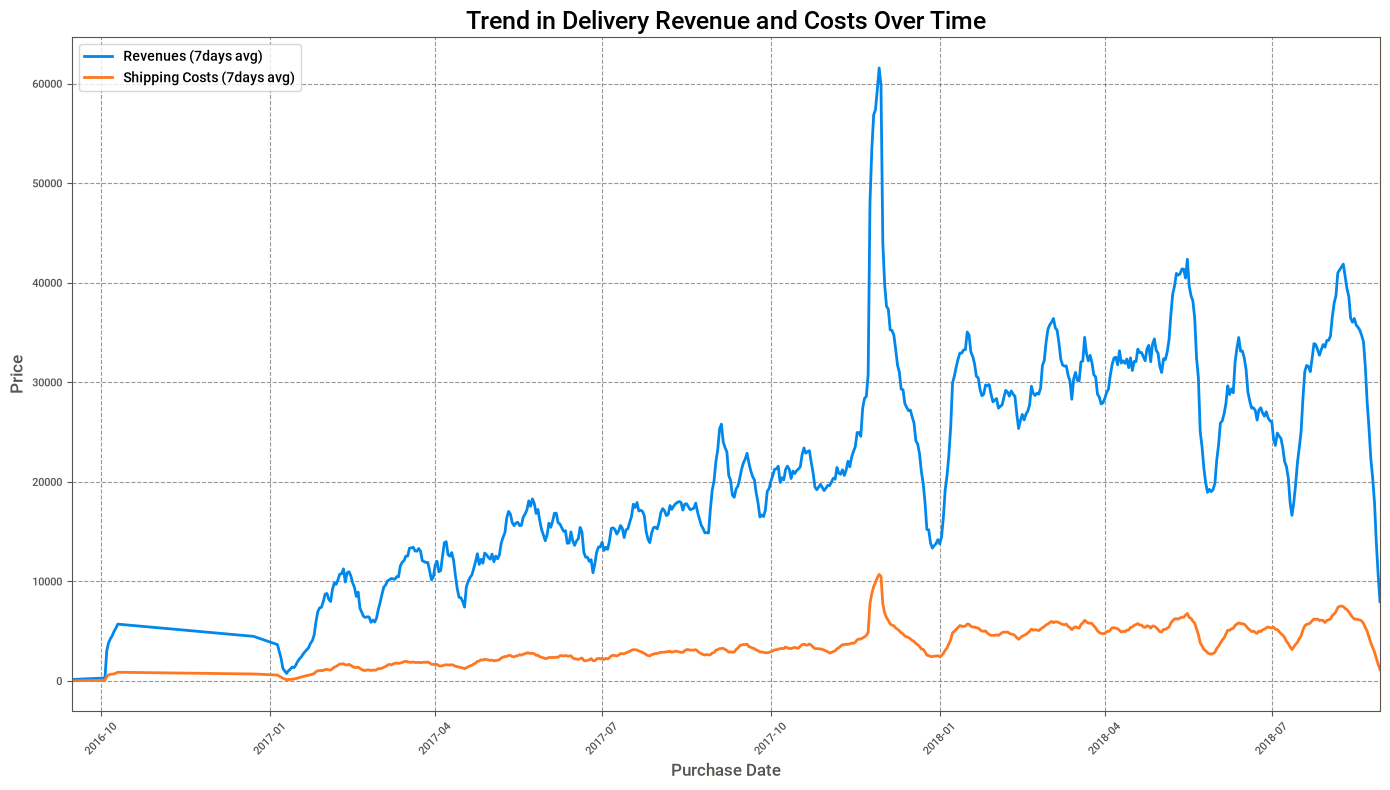

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
df['purchase_date'] = df['order_purchase_timestamp'].dt.date
daily_data = df.groupby('purchase_date')[['price','freight_value']].sum().reset_index()
daily_data['price_7d_avg'] = daily_data['price'].rolling(window=7, min_periods=1).mean()
daily_data['freight_value_7d_avg'] = daily_data['freight_value'].rolling(window=7, min_periods=1).mean()
df_melted = daily_data.melt(
    id_vars='purchase_date',
    value_vars=['price_7d_avg','freight_value_7d_avg'],
    var_name='Metric',
    value_name='Value'
)

df_melted['Metric'] = df_melted['Metric'].replace({
    'price_7d_avg': 'Revenues (7days avg)',
    'freight_value_7d_avg': 'Shipping Costs (7days avg)',
})
#display(df_melted.head(15))
plt.figure(figsize=(14,8))
lplot=sns.lineplot(
    data=df_melted,
    x='purchase_date',
    y='Value',
    hue='Metric',
    linewidth=2,
    legend="brief"
)
first_date = df_melted['purchase_date'].min()
last_date = df_melted['purchase_date'].max()
lplot.set_xlim(first_date, last_date)

plt.title("Trend in Delivery Revenue and Costs Over Time", fontsize=18, fontweight='bold',color='black')
plt.xlabel("Purchase Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True,linestyle='--', alpha=0.6)
plt.legend(loc='upper left',frameon=True)
plt.tight_layout()
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19048\3728721605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_states, x='customer_state', y='freight_value', palette="Set3")


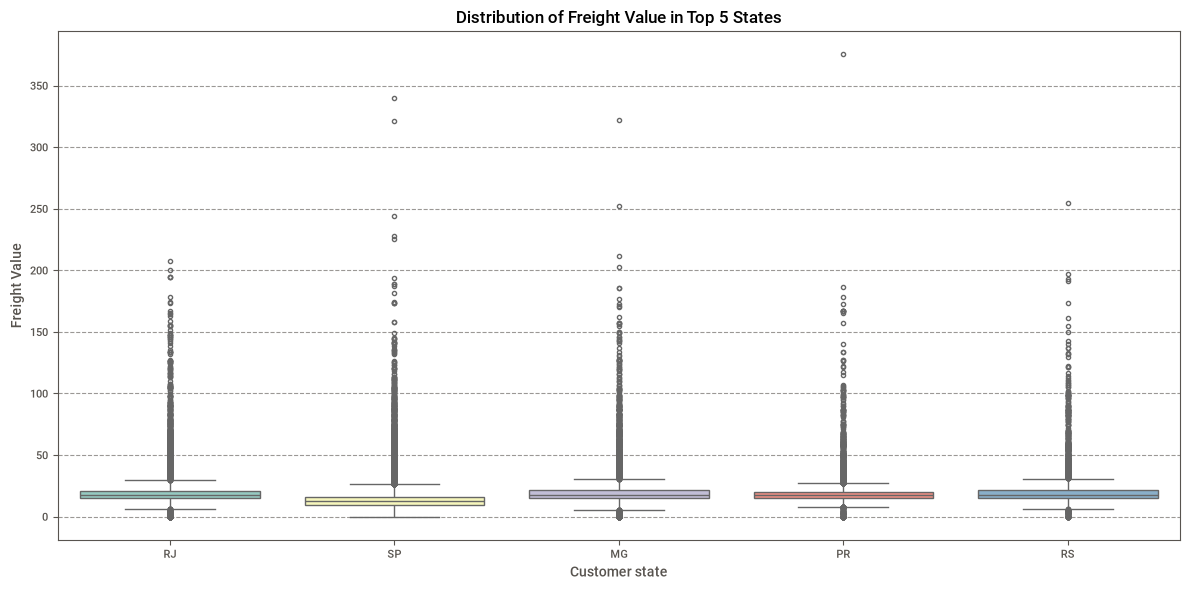

In [21]:
top5_states = df['customer_state'].value_counts().nlargest(5).index
df_top_states = df[df['customer_state'].isin(top5_states)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_states, x='customer_state', y='freight_value', palette="Set3")

plt.title("Distribution of Freight Value in Top 5 States")
plt.xlabel("Customer state")
plt.ylabel("Freight Value")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

findfont: Failed to find font weight normal, now using 500.


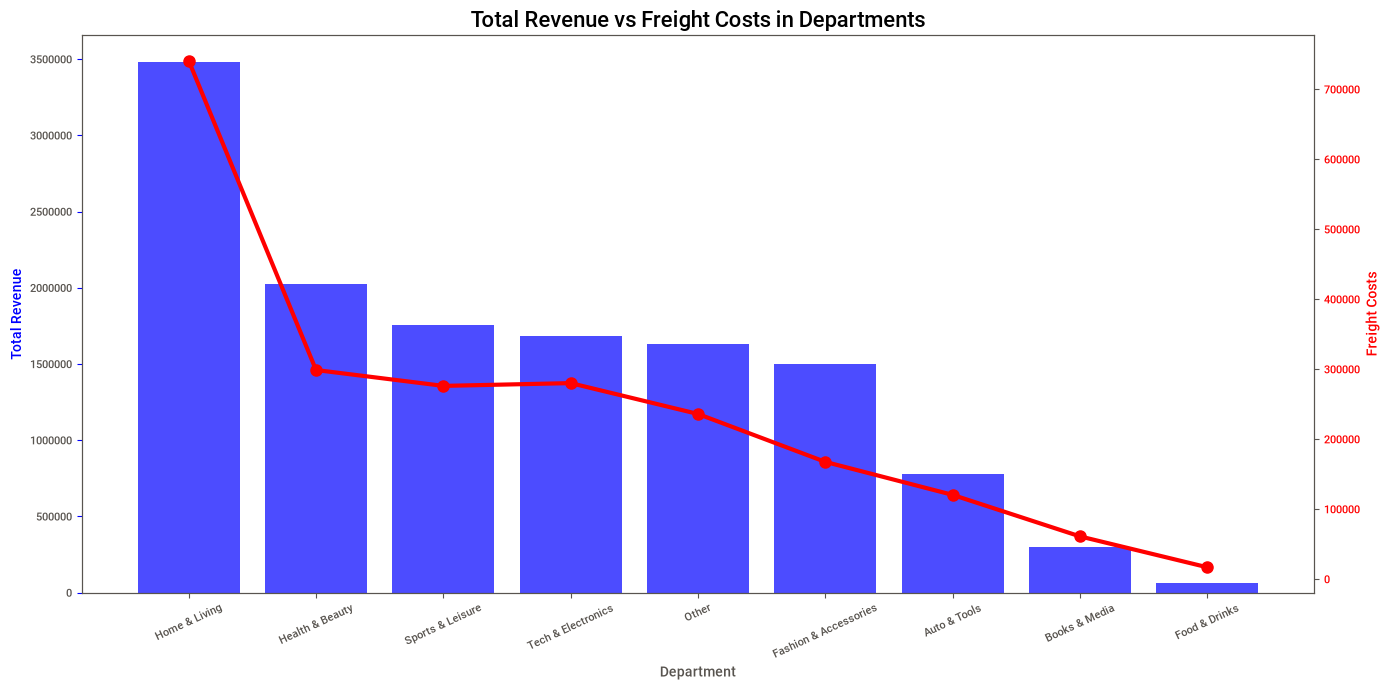

In [22]:
dept_metrics = df.groupby('department')[['price','freight_value']].sum().nlargest(10,'price').reset_index()
fig, fig1 = plt.subplots(figsize=(14,7))
fig1.set_xlabel('Department', fontsize=10)
fig1.set_ylabel('Total Revenue', color='blue' )
fig1.bar(dept_metrics['department'], dept_metrics['price'], color='blue', alpha=0.7, label='Revenue')
fig1.tick_params(axis='y', color='blue')
fig1.tick_params(axis='x', rotation=25)

fig2 = fig1.twinx()
fig2.set_ylabel('Freight Costs', color = 'red')
fig2.plot(dept_metrics['department'], dept_metrics['freight_value'], color='red', marker='o', linewidth=3, markersize=8, label='Freight Costs')
fig2.tick_params(axis='y', labelcolor='red')

plt.title("Total Revenue vs Freight Costs in Departments", fontsize=16)
fig.tight_layout()

plt.show()



Time-Series Trend: The massive revenue spike in November 2017 (Black Friday) proved Olist's infrastructure could handle immense traffic, serving as a tipping point that doubled their daily baseline sales and led to explosive growth during Mother’s and Father’s Day in 2018.

Distribution Boxplot: São Paulo (SP) is the most optimized logistics hub with the lowest and most predictable freight costs, whereas states like Rio de Janeiro (RJ) and Minas Gerais (MG) suffer from extreme positive outliers due to remote delivery challenges.

Dual-Axis Comparison: "Home & Living" is the top revenue-generating department but concurrently incurs the highest absolute freight costs, strongly suggesting that bulky or heavy items significantly impact the platform's logistical expenses.

1. What is "long" (tidy) format and why is it convenient?

The "long" (or tidy) data format involves transforming multiple metric columns into just two columns: one identifying the metric's name and one containing its numerical value. This structure is highly convenient for visualization libraries like Seaborn. By passing the column with metric names to the hue parameter, the library automatically groups the data and generates multiple colored lines. To achieve this in the first trend chart, the pd.melt() method was applied to create a structured dataframe with 'Metric' and 'Value' columns.

2. Which method was used for the comparison chart and why?

For the metric comparison chart (Total Revenue vs. Freight Costs in Departments), the long data format was not utilized. Instead, the .groupby('department')[['price', 'freight_value']].sum() method was used to aggregate the data while keeping the metrics in separate columns (wide format). This specific method was chosen because it enables the use of Matplotlib's twinx() function, allowing both metrics to be plotted on two separate Y-axes. If the data had been melted and plotted on a single axis, the massive difference in numerical scales would have completely flattened the "Freight Costs" line, making the comparison unreadable.

In [24]:
unique_states = df['customer_state'].unique()
geo = pd.read_csv('olist_geolocation_dataset.csv')
state_cords = geo.groupby('geolocation_state')[['geolocation_lat','geolocation_lng']].mean().reset_index()
state_cords.rename(columns={'geolocation_state': 'customer_state'}, inplace=True)
map_data = df.groupby('customer_state', as_index=False)[['price','freight_value']].sum()
map_data = map_data.merge(state_cords, on='customer_state', how='left')

fig_map = px.scatter_geo(
    map_data,
    lat='geolocation_lat',
    lon='geolocation_lng',
    size='price',
    color='freight_value',
    hover_name='customer_state',
    title='Interactive Map: Revenue(size) and Freight Value by State',
    scope='south america',
    color_continuous_scale='Turbo'
)
fig_map.update_traces(marker=dict(line=dict(width=1, color='black')))
fig_map.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_map.show()

In [25]:
region_manager_map = {
    'SP': 'Sarah (Southeast)', 'RJ': 'Sarah (Southeast)', 'MG': 'Sarah (Southeast)', 'ES': 'Sarah (Southeast)',
    'PR': 'John (South)', 'RS': 'John (South)', 'SC': 'John (South)',
    'BA': 'Michael (Northeast)', 'PE': 'Michael (Northeast)', 'CE': 'Michael (Northeast)',
    'MA': 'Michael (Northeast)', 'PB': 'Michael (Northeast)', 'RN': 'Michael (Northeast)',
    'AL': 'Michael (Northeast)', 'PI': 'Michael (Northeast)', 'SE': 'Michael (Northeast)',
    'AM': 'Anna (North)', 'PA': 'Anna (North)', 'RO': 'Anna (North)', 'TO': 'Anna (North)',
    'AC': 'Anna (North)', 'AP': 'Anna (North)', 'RR': 'Anna (North)',
    'DF': 'Mark (Midwest)', 'GO': 'Mark (Midwest)', 'MT': 'Mark (Midwest)', 'MS': 'Mark (Midwest)'
}
df['regional_manager'] = df['customer_state'].map(region_manager_map)
top8_dept = df['department'].value_counts().nlargest(8).index
df['main_dept'] = df['department'].where(df['department'].isin(top8_dept),'Other')
tree_data =df.groupby(['regional_manager','customer_state','main_dept'], as_index=False).agg({
    'price':'sum',
    'freight_value':'mean'
})

fig_tree = px.treemap(
    tree_data,
    path=['regional_manager','customer_state','main_dept'],
    values='price',
    color='freight_value',
    color_continuous_scale='YlOrRd', 
    range_color=[15, 50], 
    title='Drill-down: Regional Manager ➔ State ➔ Main Department'
)
fig_tree.update_traces(
    textinfo='label+value'
)
fig_tree.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    template='plotly_white',
    paper_bgcolor='white'
)
fig_tree.show()

Based on the hierarchical Treemap, it is clearly visible that the most problematic areas regarding high freight costs (the darkest red color) are located in the regions managed by Michael (Northeast) and Anna (North).

- Specifically, within Michael's region, states such as AL and MA exhibit the highest average transport costs, reaching the upper limit of the color scale.

- Similarly, in Anna's territory (North), all visible states (PA, TO, AM, RO) experience very high shipping costs, highlighted in deep red.

- Interestingly, scatter map reveals that the highest total revenue and the highest absolute sum of freight costs are concentrated in a single location in the Southeast, specifically around the state of São Paulo.

- This indicates that while the Southeast generates massive total logistical costs due to sheer volume, managers in the North and Northeast face lower sales volumes but exceptionally high unit shipping costs, which severely erode profit margins.

If I were managing Michael's region (Northeast), I would implement two strategies:

1) Localized Fulfillment: Initiate partnerships with local suppliers or establish a micro-fulfillment center closer to high-cost states like AL and MA. This would help bypass the extremely expensive cross-country shipping originating from the central and southern hubs.

2) Dynamic Pricing Strategy: Modify the shipping cost policy by introducing dynamic transport fees for the most remote states, or strategically focus marketing efforts exclusively on the highest-margin product categories to offset the severe logistical losses.

Differences Between Methods:

- pd.merge(): Functions identically to an SQL JOIN. It is the most robust method for combining two DataFrames based on a shared common column (or multiple columns). It allows for various join types.

- DataFrame.join(): A specialized method designed to combine DataFrames horizontally by aligning their row indices rather than standard columns. It is most efficient when working with time-series or index-heavy data.

- Series.map(): A highly efficient function applied to a single column (Series) that substitutes each existing value with a new one based on a provided Python dictionary, function, or another Series.

Chosen Approach and Rationale:
To enrich the dataset with the assigned Managers, the Series.map() method was utilized. Task required establishing a simple, static relationship between the Brazilian states and Regional Managers, using a standard Python dictionary was the most optimal solution. Applying .map() directly to the customer_state column was significantly faster and was more memory-efficient than artificially creating an additional DataFrame solely to execute a pd.merge() operation.

In [26]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_metr = df.groupby('order_month').agg(
    total_revenue=('price','sum'),
    total_orders=('order_id','nunique'),
    unique_customers=('customer_unique_id', 'nunique')
).reset_index()

monthly_metr['AOV'] = monthly_metr['total_revenue'] / monthly_metr['total_orders']
monthly_metr['ARPU'] = monthly_metr['total_revenue'] / monthly_metr['unique_customers']

monthly_metr['order_month_str'] = monthly_metr['order_month'].astype(str)
fig_metrics = px.line(
    monthly_metr,
    x='order_month_str',
    y=['AOV','ARPU'],
    title="Monthly Dynamics: Average Order Value vs. Average Revenue Per User",
    labels={'value': 'BRL', 'order_month_str': 'month', 'variable':'metric'}
)
fig_metrics.update_layout(template='plotly_white',hovermode='x unified')
fig_metrics.show()


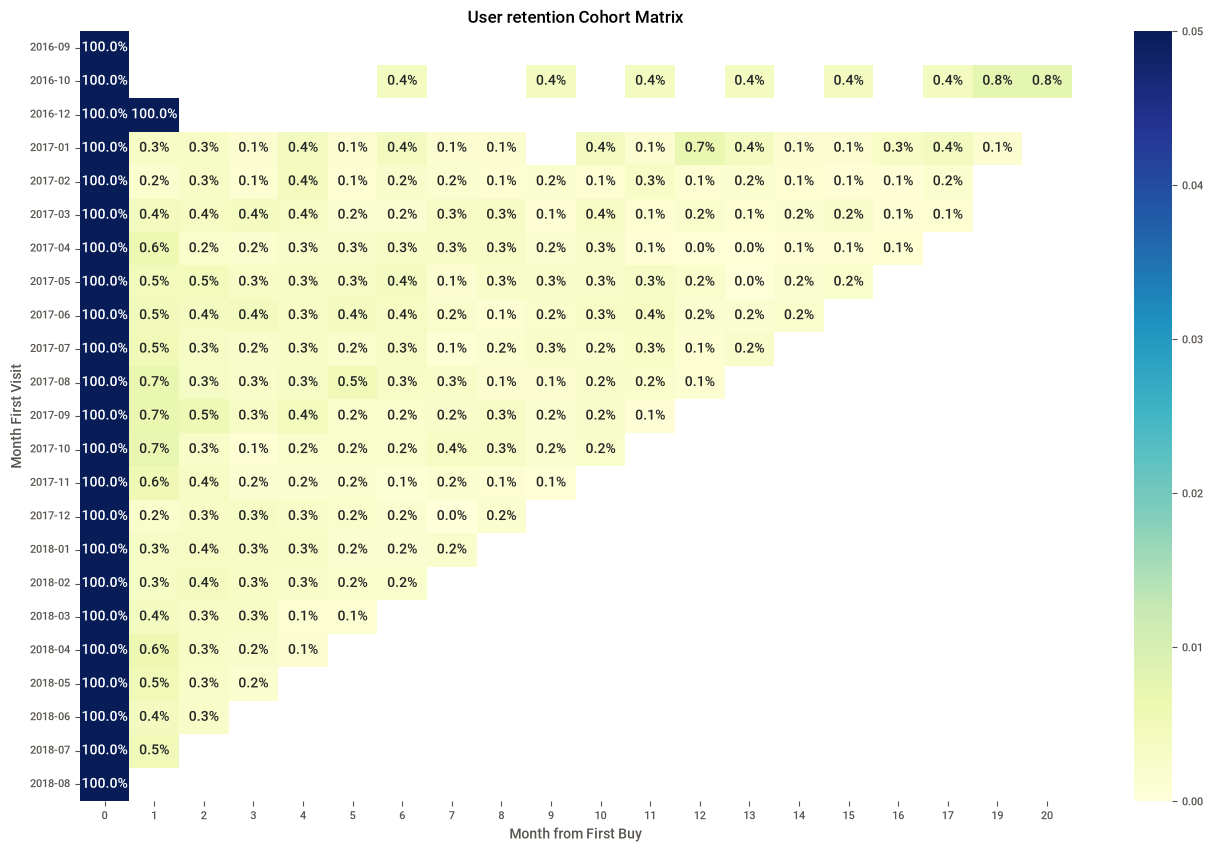

In [27]:

df['cohort_month'] = df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
df['cohort_index'] = (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 + (df['order_month'].dt.month - df['cohort_month'].dt.month)
cohort_data = df.groupby(['cohort_month','cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month',columns='cohort_index', values='customer_unique_id')
cohort_sizes = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)
plt.figure(figsize=(16,10))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='YlGnBu',
    vmin=0.0,
    vmax=0.05
)
plt.title("User retention Cohort Matrix")
plt.ylabel('Month First Visit')
plt.xlabel("Month from First Buy")
plt.show()

In [28]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_unique_id').agg(
    Recency = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id','nunique'),
    Monetary = ('price', 'sum')
).reset_index()

rfm['m_score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])
rfm['r_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])

def assign_seg(row):
    r,f,m = row['r_score'], row['f_score'], row['m_score']

    if r==4 and f>=3 and m>=3:
        return 'Champion'
    elif r<=2 and f>=3:
        return 'At risk'
    else:
        return 'Regulars'

rfm['segment'] = rfm.apply(assign_seg, axis=1)
seg_to_show = ['Champion', 'At risk', 'Regulars']
for seg in seg_to_show:
    print(f'\n---Top 5: {seg}---')
    top5 = rfm[rfm['segment'] == seg].sort_values(by='Monetary', ascending=False).head(5)
    display(top5)



---Top 5: Champion---


,customer_unique_id,Recency,Frequency,Monetary,m_score,r_score,f_score,segment
59151,a229eba70ec1c2abef51f04987deb7a5,90,1,4400.00,4,4,3,Champion
86836,edde2314c6c30e864a128ac95d6b2112,26,1,4399.87,4,4,4,Champion
73112,c8460e4251689ba205045f3ea17884a1,22,4,4080.00,4,4,4,Champion
73811,ca27f3dac28fb1063faddd424c9d95fa,32,1,4059.00,4,4,4,Champion
87723,f0767ae738c3d90e7b737d7b8b8bb4d1,107,1,3930.00,4,4,4,Champion



---Top 5: At risk---


,customer_unique_id,Recency,Frequency,Monetary,m_score,r_score,f_score,segment
79619,da122df9eeddfedc1dc1f5349a1a690c,515,2,7388.0,4,1,4,At risk
80446,dc4802a71eae9be1dd28f5d788ceb526,563,1,6735.0,4,1,4,At risk
93062,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,6499.0,4,1,4,At risk
87129,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,4690.0,4,1,4,At risk
86871,edf81e1f3070b9dac83ec83dacdbb9bc,498,1,3999.0,4,1,4,At risk



---Top 5: Regulars---


,customer_unique_id,Recency,Frequency,Monetary,m_score,r_score,f_score,segment
3723,0a0a92112bd4c708ca5fde585afaa872,334,1,13440.0,4,2,1,Regulars
43160,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7160.0,4,4,2,Regulars
25432,459bef486812aa25204be022145caa62,35,1,6729.0,4,4,2,Regulars
23407,4007669dec559734d6f53e029e360987,279,1,5934.6,4,2,1,Regulars
26636,48e1ac109decbb87765a3eade6854098,69,1,4590.0,4,4,2,Regulars


Customer Drop-off: We lose the vast majority of our user base (>99%) immediately by Month 1 (the very next month after their initial purchase). The cohort matrix demonstrates a brutal drop from 100% in Month 0 to roughly 0.1%–0.3% in Month 1, confirming Olist operates as a purely transactional marketplace rather than a loyalty-driven storefront.

1) Action Plan – Champions: Because they bought recently and spent heavily, the goal is capitalization and advocacy, not discounting. Action: Deploy automated review requests to build platform trust, offer "VIP" priority free shipping on their next order, or trigger cross-sell emails featuring high-margin accessories directly related to their recent large purchase.

2) Action Plan – At Risk: These users have proven they can spend large amounts (High Monetary) but have not returned in over a year (Low Recency). Action: Deploy an aggressive "win-back" campaign featuring a significant, time-sensitive discount code (e.g., 20% off). Because their historical basket size is so large, the high potential ROI justifies the immediate margin hit of a heavy discount.



Categorical Columns:
- np.where() / np.select(): Highly performant but readability plummets when dealing with complex, multi-column conditions.
- pd.qcut() / pd.cut(): Excellent performance and highly readable, specifically designed for binning continuous numerical data into quantiles or fixed intervals.
- .apply(function, axis=1): The slowest method (iterates row-by-row in Python), but offers maximum readability and flexibility for complex, custom business logic.

Our Approach for RFM: We used a hybrid approach. We utilized pd.qcut() to generate the R, F, and M scores because it natively handles the complex math of dividing data into equal percentiles. We then used .apply() with a custom function (assign_seg) for the final segmentation. The business rules required evaluating three distinct variables (R, F, M) simultaneously—in this case, the readability and ease of modifying the business logic far outweighed the minor performance hit.

    groupby().min() aggregates the data, returning a DataFrame with a smaller shape

    transform('min') calculates that same group minimum but broadcasts the value back to the original shape of the DataFrame (returning a Series of the exact same length as the raw data).

Conclusion: .transform('min') is the strictly superior choice for adding a new column directly to the original DataFrame. It aligns perfectly with the existing index, completely bypassing the need to perform a costly and verbose pd.merge() to rejoin aggregated data back to the main table.

In [29]:
df.to_csv('olist_cleaned_dataset_ground_truth.csv', index=False)
rfm.to_csv('olist_rfm_segmentation.csv', index=False)
